# Implementing a boosting model
## to be investigated is which features to pick and which boosing methods works best 
## What is boosting ?
Boosting is a methods of modelling where we group together multiple weaker learning models together inforder to make a bigger more sophisticated model.


These are usually smaller decision trees

The final prediction is  **weighted combination** of all learners
## Examples of boosting methods:
- Ada boosting
- Gradient boosting

### Gradient Boosting 
First tree is trained on the original data and labels Subsequent trees are trained on residual errors of the previous tree 

### Difference between bosting and bagging
Bagging (Bootstrap Aggregating) and boosting are ensemble methods used to improve machine learning model performance. Bagging trains models in parallel on random data subsets to reduce variance and prevent overfitting (e.g., Random Forest). Boosting trains models sequentially, where each new model focuses on correcting errors from previous ones, reducing bias and improving accuracy, but with a higher risk of overfitting.

Bagging - reduces variance (Overfitting)
Boosting - reduces bias (Underfitting)




In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score,f1_score, confusion_matrix, classification_report
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor


## Importing the cleaned dataset

In [18]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

## Feature Selection

In [ ]:
features = [
    'ZSx [s]',        # injection time
    'ACPx [cm³]',     # cushion volume
    'ZDx [s]',        # dosing time
            # cycle time  'ZUs [s]', 
    'ZEx [s]',        # (keep if it’s meaningful in your process)
    'GEx [kWh]',      # energy consumption
    'H16x [°C]',
    'H10x [°C]'       # temperature 2
]

X = dataset[features].copy()
y = dataset['ASZ [Sch]'].astype(int).copy()

print("X shape:", X.shape)
print("y positives:", y.sum(), " / ", len(y))


X shape: (4854, 6)
y positives: 163  /  4854


## Split and Scale

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Implementing the gradient boosing Classifier

F1 score: 0.5084745762711864
Confusion matrix:
 [[927   6]
 [ 23  15]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       933
           1       0.71      0.39      0.51        38

    accuracy                           0.97       971
   macro avg       0.85      0.69      0.75       971
weighted avg       0.97      0.97      0.97       971



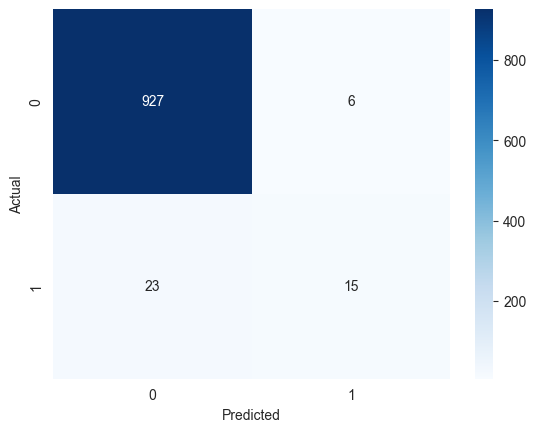

Stored 'gbc_cr' (dict)


In [21]:
gbc = GradientBoostingClassifier(random_state=42, n_estimators=400)
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Store classification report
gbc_cr = classification_report(y_test,y_pred,output_dict=True)
%store gbc_cr

In [22]:
#storing classification report

gbc_cr = classification_report(y_test, y_pred, output_dict=True)

%store gbc_cr


Stored 'gbc_cr' (dict)


## Gradient boosing Regressor 

MSE: 0.0250
RMSE: 0.1582
MAE: 0.0471
R2: 0.3342


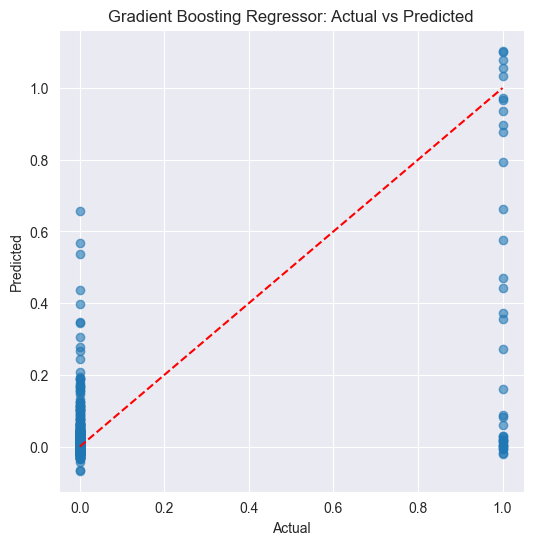

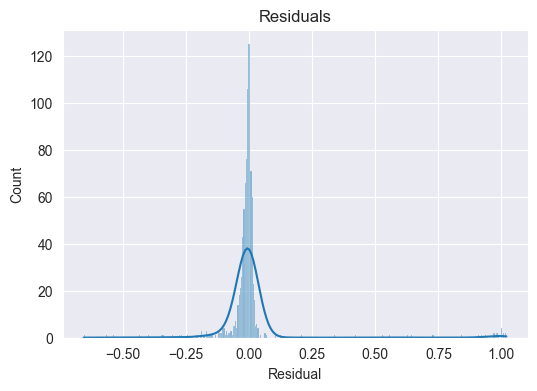

Feature importances:
 GEx [kWh]     0.500471
H10x [°C]     0.192742
ZSx [s]       0.153909
ZDx [s]       0.065568
ZEx [s]       0.051841
ACPx [cm³]    0.035468
dtype: float64


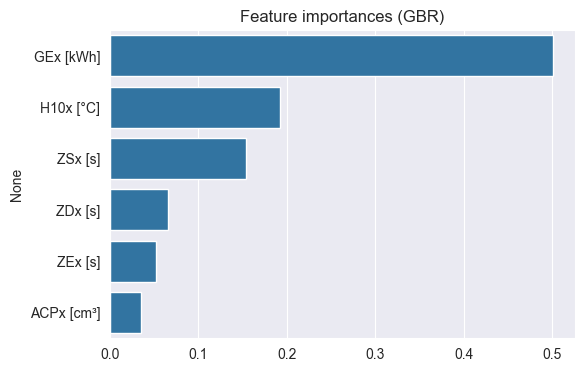

In [23]:

gbr = GradientBoostingRegressor(random_state=42, n_estimators=400)
gbr.fit(X_train, y_train)

y_pred_reg = gbr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_reg, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Gradient Boosting Regressor: Actual vs Predicted')
plt.show()

# Residuals
residuals = y_test - y_pred_reg
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title('Residuals')
plt.xlabel('Residual')
plt.show()

# Feature importances
importances = gbr.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("Feature importances:\n", feat_imp)
plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature importances (GBR)')
plt.show()

In [24]:
%store gbr gbc 

Stored 'gbr' (GradientBoostingRegressor)
Stored 'gbc' (GradientBoostingClassifier)


## Difference between the Gradient boosting regressor and Classifier
- Purpose  
    - Regressor: predict a continuous numeric target (e.g., temperature, time).  
    - Classifier: predict discrete class labels (e.g., defective / ok).

- Objective / loss  
    - Regressor: minimizes a regression loss (typically squared error / MSE).  
    - Classifier: minimizes a classification loss (typically deviance / logistic log‑loss for binary).

- Output  
    - Regressor: real-valued predictions.  
    - Classifier: class labels via predict(); class probabilities via predict_proba().

- Evaluation metrics  
    - Regressor: MSE, RMSE, MAE, R².  
    - Classifier: accuracy, precision/recall/F1, ROC‑AUC, confusion matrix.

- Thresholding / decision making  
    - Regressor: no threshold; you can post‑process continuous output if needed.  
    - Classifier: decision threshold (default 0.5 for binary) converts probabilities to class labels.

- Hyperparameters & behavior  
    - Both share most hyperparameters (n_estimators, learning_rate, max_depth, subsample, etc.).  
    - Choice of loss and labels/targets is what distinguishes training behavior.

- Data requirements  
    - Regressor: numeric continuous target.  
    - Classifier: discrete labels (may need encoding); for imbalanced classes consider class_weight, sampling, or threshold tuning.

- Interpretation  
    - Both provide feature_importances_. For classifiers also inspect class-wise probabilities and calibration.

Use the regressor when your target is continuous; use the classifier when you need class membership or probabilities for categorical outcomes.